## BERT预训练

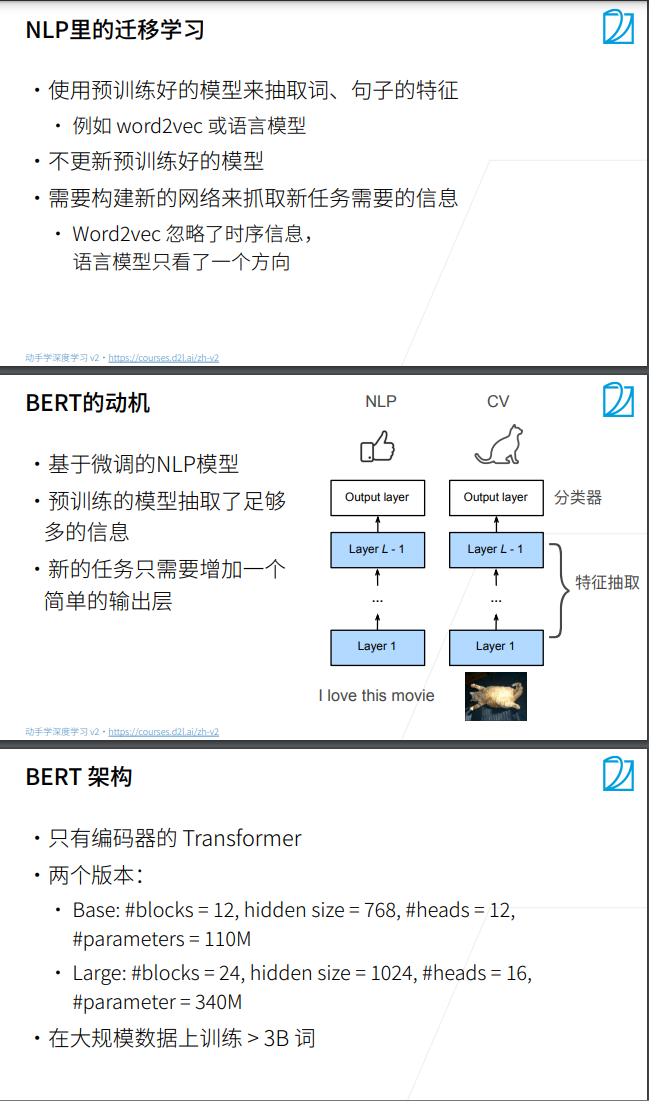
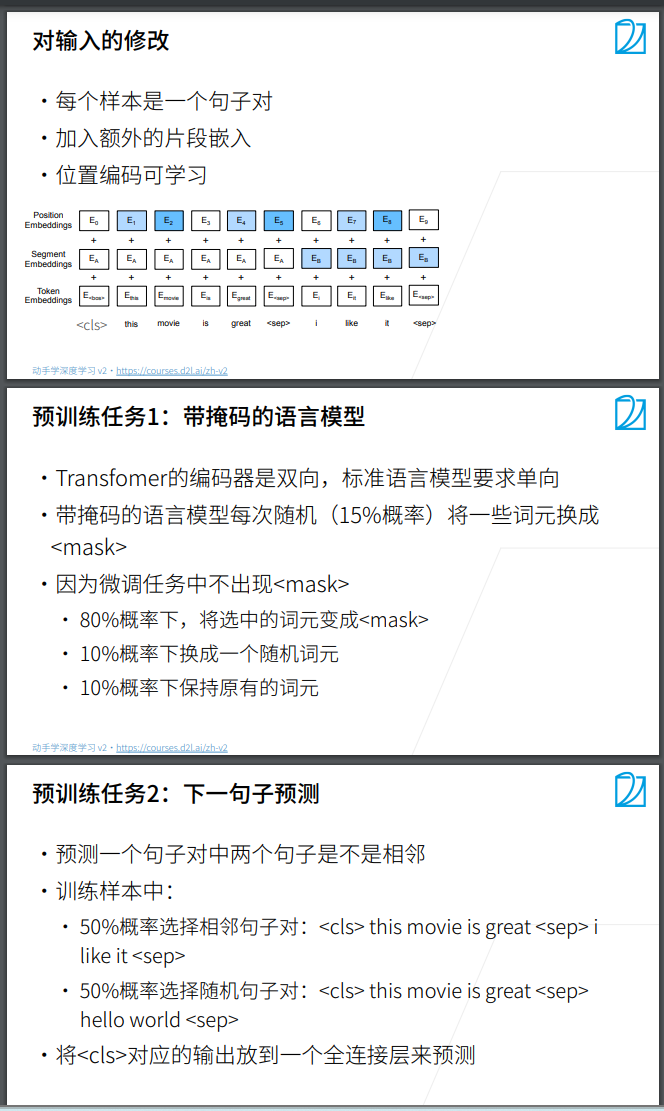
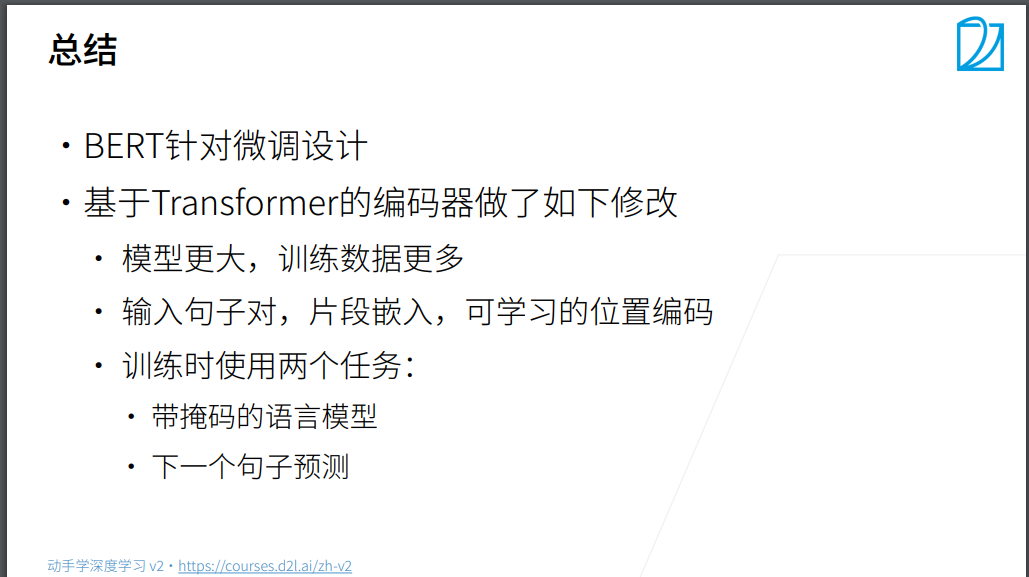

word2vec只是改变embedding的输入 具体的后续模型还是要自己改的  我们期望的是预训练一个大模型

由于只有一个encoder， QA很多情况下是两个句子，于是就用句子对的形式输入。cls作为开头，sep作为句子间的分割。额外的片段嵌入就是给第一个句子给id是0，第二个句子给个id是1...

语言模型给一个句子预测下一个词，但是bert是个encoder能够看到后面的。所以加一个mask，80%mask用来训练模型有效抓去信息，10%用来提升鲁棒性，10%用来保持和微调时同样的分布。（相当于做完形填空来训练模型 得到双向信息）。微调不出现mask，是在预训练任务中减少一见到mask就进行预测，所以20%的概率不出现mask

还有第二个任务，是连线题。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
#@save
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """获取输入序列的词元及其片段索引"""
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0和1分别标记片段A和B
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

In [8]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [9]:
#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(
             num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [3]:
#@save
class BERTEncoder(nn.Module):
    """BERT编码器"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens) # 0或者1
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", d2l.EncoderBlock(
                key_size, query_size, value_size, num_hiddens, norm_shape,
                ffn_num_input, ffn_num_hiddens, num_heads, dropout, True))
        # 在BERT中，位置嵌入是可学习的，因此我们创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # 在以下代码段中，X的形状保持不变：（批量大小，最大序列长度，num_hiddens）
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

In [12]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [4]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
norm_shape, ffn_num_input, num_layers, dropout = [768], 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape, ffn_num_input,
                      ffn_num_hiddens, num_heads, num_layers, dropout)

AttributeError: module 'd2l.torch' has no attribute 'EncoderBlock'

In [31]:
#@save
class MYBERTEncoder(nn.Module):
    """BERT编码器"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 **kwargs):
        super(MYBERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens) # 0或者1
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", d2l.TransformerEncoderBlock(
                 num_hiddens, ffn_num_hiddens, num_heads, dropout, True))
        # 在BERT中，位置嵌入是可学习的，因此我们创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # 在以下代码段中，X的形状保持不变：（批量大小，最大序列长度，num_hiddens）
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

In [32]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
norm_shape, ffn_num_input, num_layers, dropout = [768], 768, 2, 0.2
myencoder = MYBERTEncoder(vocab_size, num_hiddens, norm_shape, ffn_num_input,
                      ffn_num_hiddens, num_heads, num_layers, dropout)

D:\Pycharm\venv\lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [33]:
tokens = torch.randint(0, vocab_size, (2, 8))  # batchsize为2 长度为8
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
myencoded_X = myencoder(tokens, segments, None)
myencoded_X.shape

torch.Size([2, 8, 768])

In [10]:
#@save
class BERTEncoder(nn.Module):
    """BERT编码器"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens) # 0或者1
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", EncoderBlock(
                num_hiddens, norm_shape,
                ffn_num_input, ffn_num_hiddens, num_heads, dropout, True))
        # 在BERT中，位置嵌入是可学习的，因此我们创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # 在以下代码段中，X的形状保持不变：（批量大小，最大序列长度，num_hiddens）
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

In [13]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
norm_shape, ffn_num_input, num_layers, dropout = [768], 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape, ffn_num_input,
                      ffn_num_hiddens, num_heads, num_layers, dropout)

In [14]:
tokens = torch.randint(0, vocab_size, (2, 8))  # batchsize为2 长度为8
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])

In [15]:
tokens

tensor([[6570, 5198, 4150, 7122, 9977, 7571, 5951, 8056],
        [6085, 5884, 3647,  766, 2965, 7602, 9157, 9417]])

In [16]:
#@save
class MaskLM(nn.Module):
    """BERT的掩蔽语言模型任务"""
    def __init__(self, vocab_size, num_hiddens, num_inputs=768, **kwargs):
        super(MaskLM, self).__init__(**kwargs)
        self.mlp = nn.Sequential(nn.Linear(num_inputs, num_hiddens),
                                 nn.ReLU(),
                                 nn.LayerNorm(num_hiddens),
                                 nn.Linear(num_hiddens, vocab_size))

    def forward(self, X, pred_positions):  # pred_positions是需要预测的位置
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # 假设batch_size=2，num_pred_positions=3
        # 那么batch_idx是np.array（[0,0,0,1,1,1]）
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        masked_X = X[batch_idx, pred_positions]  # 把对应位置的特征拿出来 用来做分类
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

In [18]:
torch.arange(0, 3).reshape(-1)

tensor([0, 1, 2])

In [19]:
mlm = MaskLM(vocab_size, num_hiddens)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])  # 第一个batch要预测的位置是1,5,2
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape  # batch num_pred_positions vocab_size

torch.Size([2, 3, 10000])

In [21]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction='none')
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l.shape, mlm_l

(torch.Size([6]),
 tensor([9.5609, 8.5803, 9.8414, 9.8020, 8.2033, 7.7973],
        grad_fn=<NllLossBackward0>))

In [22]:
#@save
class NextSentencePred(nn.Module):
    """BERT的下一句预测任务"""
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)  # 是一个单分类问题

    def forward(self, X):
        # X的形状：(batchsize,num_hiddens)
        return self.output(X)

In [23]:
encoded_X = torch.flatten(encoded_X, start_dim=1)
# NSP的输入形状:(batchsize，num_hiddens)
nsp = NextSentencePred(encoded_X.shape[-1])
nsp_Y_hat = nsp(encoded_X)
nsp_Y_hat.shape

torch.Size([2, 2])

In [24]:
nsp_y = torch.tensor([0, 1])
nsp_l = loss(nsp_Y_hat, nsp_y)
nsp_l.shape

torch.Size([2])

In [25]:
#@save
class BERTModel(nn.Module):
    """BERT模型"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 hid_in_features=768, mlm_in_features=768,
                 nsp_in_features=768):
        super(BERTModel, self).__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape,
                    ffn_num_input, ffn_num_hiddens, num_heads, num_layers,
                    dropout, max_len=max_len, key_size=key_size,
                    query_size=query_size, value_size=value_size)
        self.hidden = nn.Sequential(nn.Linear(hid_in_features, num_hiddens),
                                    nn.Tanh())
        self.mlm = MaskLM(vocab_size, num_hiddens, mlm_in_features)
        self.nsp = NextSentencePred(nsp_in_features)

    def forward(self, tokens, segments, valid_lens=None,
                pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        # 用于下一句预测的多层感知机分类器的隐藏层，0是“<cls>”标记的索引
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

### 预训练数据代码

In [34]:
import os
import random
import torch
from d2l import torch as d2l

In [35]:
#@save
d2l.DATA_HUB['wikitext-2'] = (
    'https://s3.amazonaws.com/research.metamind.io/wikitext/'
    'wikitext-2-v1.zip', '3c914d17d80b1459be871a5039ac23e752a53cbe')

#@save
def _read_wiki(data_dir):
    file_name = os.path.join(data_dir, 'wiki.train.tokens')
    with open(file_name, 'r') as f:
        lines = f.readlines()
    # 大写字母转换为小写字母
    paragraphs = [line.strip().lower().split(' . ')
                  for line in lines if len(line.split(' . ')) >= 2]
    random.shuffle(paragraphs)
    return paragraphs

In [36]:
#@save  得到连线题的样本
def _get_next_sentence(sentence, next_sentence, paragraphs):
    if random.random() < 0.5:
        is_next = True
    else:
        # paragraphs是三重列表的嵌套
        next_sentence = random.choice(random.choice(paragraphs))
        is_next = False
    return sentence, next_sentence, is_next

In [37]:
#@save
def _get_nsp_data_from_paragraph(paragraph, paragraphs, vocab, max_len):
    nsp_data_from_paragraph = []
    for i in range(len(paragraph) - 1):
        tokens_a, tokens_b, is_next = _get_next_sentence(
            paragraph[i], paragraph[i + 1], paragraphs)
        # 考虑1个'<cls>'词元和2个'<sep>'词元
        if len(tokens_a) + len(tokens_b) + 3 > max_len:
            continue
        tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)
        nsp_data_from_paragraph.append((tokens, segments, is_next))
    return nsp_data_from_paragraph

In [38]:
#@save  得到填空题的样本
def _replace_mlm_tokens(tokens, candidate_pred_positions, num_mlm_preds,
                        vocab):
    # 为遮蔽语言模型的输入创建新的词元副本，其中输入可能包含替换的“<mask>”或随机词元
    mlm_input_tokens = [token for token in tokens]
    pred_positions_and_labels = []
    # 打乱后用于在遮蔽语言模型任务中获取15%的随机词元进行预测
    random.shuffle(candidate_pred_positions)
    for mlm_pred_position in candidate_pred_positions:
        if len(pred_positions_and_labels) >= num_mlm_preds:
            break
        masked_token = None
        # 80%的时间：将词替换为“<mask>”词元
        if random.random() < 0.8:
            masked_token = '<mask>'
        else:
            # 10%的时间：保持词不变
            if random.random() < 0.5:
                masked_token = tokens[mlm_pred_position]
            # 10%的时间：用随机词替换该词
            else:
                masked_token = random.choice(vocab.idx_to_token)
        mlm_input_tokens[mlm_pred_position] = masked_token
        pred_positions_and_labels.append(
            (mlm_pred_position, tokens[mlm_pred_position]))
    return mlm_input_tokens, pred_positions_and_labels  # 因为20%的不是换成mask 不存在位置以后不知道所以给了位置

In [39]:
#@save
def _get_mlm_data_from_tokens(tokens, vocab):
    candidate_pred_positions = []
    # tokens是一个字符串列表
    for i, token in enumerate(tokens):
        # 在遮蔽语言模型任务中不会预测特殊词元
        if token in ['<cls>', '<sep>']:
            continue
        candidate_pred_positions.append(i)
    # 遮蔽语言模型任务中预测15%的随机词元
    num_mlm_preds = max(1, round(len(tokens) * 0.15))
    mlm_input_tokens, pred_positions_and_labels = _replace_mlm_tokens(
        tokens, candidate_pred_positions, num_mlm_preds, vocab)
    pred_positions_and_labels = sorted(pred_positions_and_labels,
                                       key=lambda x: x[0])
    pred_positions = [v[0] for v in pred_positions_and_labels]
    mlm_pred_labels = [v[1] for v in pred_positions_and_labels]
    return vocab[mlm_input_tokens], pred_positions, vocab[mlm_pred_labels]

mlm_input_tokens是经过处理的输入词元列表，其中一些词元可能被替换为<mask>，保持原词，或被随机词替换。

pred_positions包含了所有需要预测的词元的位置索引。在MLM任务中，不是所有的词元都会被遮蔽和预测，只有一部分词元（通常是15%）会被选中进行预测。

mlm_pred_labels是与pred_positions中的位置相对应的原始词元列表，这些词元是模型需要预测的目标。

In [40]:
#@save
# 函数会将每个样本的词元ID、预测位置、预测标签等进行填充，以匹配max_len指定的长度。
def _pad_bert_inputs(examples, max_len, vocab):
    max_num_mlm_preds = round(max_len * 0.15)
    all_token_ids, all_segments, valid_lens,  = [], [], []
    all_pred_positions, all_mlm_weights, all_mlm_labels = [], [], []
    nsp_labels = []
    for (token_ids, pred_positions, mlm_pred_label_ids, segments,
         is_next) in examples:
        all_token_ids.append(torch.tensor(token_ids + [vocab['<pad>']] * (
            max_len - len(token_ids)), dtype=torch.long))
        all_segments.append(torch.tensor(segments + [0] * (
            max_len - len(segments)), dtype=torch.long))  # pad的序号是0
        # valid_lens不包括'<pad>'的计数
        valid_lens.append(torch.tensor(len(token_ids), dtype=torch.float32))
        all_pred_positions.append(torch.tensor(pred_positions + [0] * (
            max_num_mlm_preds - len(pred_positions)), dtype=torch.long))
        # 填充词元的预测将通过乘以0权重在损失中过滤掉
        all_mlm_weights.append(
            torch.tensor([1.0] * len(mlm_pred_label_ids) + [0.0] * (
                max_num_mlm_preds - len(pred_positions)),
                dtype=torch.float32))
        all_mlm_labels.append(torch.tensor(mlm_pred_label_ids + [0] * (
            max_num_mlm_preds - len(mlm_pred_label_ids)), dtype=torch.long))
        nsp_labels.append(torch.tensor(is_next, dtype=torch.long))
    return (all_token_ids, all_segments, valid_lens, all_pred_positions,
            all_mlm_weights, all_mlm_labels, nsp_labels)


# 例如，如果一个样本中有3个被遮蔽词元，而最大预测数量为5，
# 那么all_mlm_weights对应的元素可能是[1.0, 1.0, 1.0, 0.0, 0.0]，
# 表示前三个位置的预测是有效的，而后两个位置的预测应该被忽略。

在MLM任务中，模型需要预测被遮蔽（masked）词元的原始词元。但是，由于输入序列被填充到固定长度，其中会包含一些实际不是预测目标的填充词元（如<pad>）。
MLM权重通过为这些非预测目标的填充词元分配0权重，确保模型在计算损失时忽略这些位置的预测。

In [41]:
#@save
class _WikiTextDataset(torch.utils.data.Dataset):
    def __init__(self, paragraphs, max_len):
        # 输入paragraphs[i]是代表段落的句子字符串列表；
        # 而输出paragraphs[i]是代表段落的句子列表，其中每个句子都是词元列表
        paragraphs = [d2l.tokenize(
            paragraph, token='word') for paragraph in paragraphs]
        sentences = [sentence for paragraph in paragraphs
                     for sentence in paragraph]
        self.vocab = d2l.Vocab(sentences, min_freq=5, reserved_tokens=[
            '<pad>', '<mask>', '<cls>', '<sep>'])
        # 获取下一句子预测任务的数据
        examples = []
        for paragraph in paragraphs:
            examples.extend(_get_nsp_data_from_paragraph(
                paragraph, paragraphs, self.vocab, max_len))
        # 获取遮蔽语言模型任务的数据
        examples = [(_get_mlm_data_from_tokens(tokens, self.vocab)
                      + (segments, is_next))
                     for tokens, segments, is_next in examples]
        # 填充输入
        (self.all_token_ids, self.all_segments, self.valid_lens,
         self.all_pred_positions, self.all_mlm_weights,
         self.all_mlm_labels, self.nsp_labels) = _pad_bert_inputs(
            examples, max_len, self.vocab)

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx], self.all_pred_positions[idx],
                self.all_mlm_weights[idx], self.all_mlm_labels[idx],
                self.nsp_labels[idx])

    def __len__(self):
        return len(self.all_token_ids)

In [50]:
import pandas as pd
def _read_wiki(data_dir):
    df = pd.read_parquet(data_dir)
    # 提取文本内容列并转换为列表
    lines = df['text'].tolist()
    print("reading")
    paragraphs = [line.strip().lower().split(' . ')
                  for line in lines if len(line.split(' . ')) >= 2]
    random.shuffle(paragraphs)#在段落间进行打乱
    return paragraphs

In [57]:
#@save
def load_data_wiki(batch_size, max_len):
    # “”“加载WikiText-2数据集”“”
    num_workers = d2l.get_dataloader_workers()
    paragraphs = _read_wiki("E:\\postgraduate\\python\\data\\train-00000-of-00001.parquet")
    train_set = _WikiTextDataset(paragraphs, max_len)#返回数据集
    train_iter = torch.utils.data.DataLoader(train_set, batch_size,
    shuffle=True, num_workers=0)
    # print(“done”)
    return train_iter, train_set.vocab

In [58]:
batch_size, max_len = 512, 64
train_iter, vocab = load_data_wiki(batch_size, max_len)

for (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X,
     mlm_Y, nsp_y) in train_iter:
    print(tokens_X.shape, segments_X.shape, valid_lens_x.shape,
          pred_positions_X.shape, mlm_weights_X.shape, mlm_Y.shape,
          nsp_y.shape)
    break  # nsp_y代表句子对是不是真正连续的
# tokens_x就是token句子  segment_X就是片段的编号嵌入
# valid_lens_x每句话多少个有用的
# pred_positions_X 哪些位置需要预测  这里设定了10个位置
# mlm_weights_X 1代表真的是预测 0代表是填充的pad（就是被挖的空时pad 这种没必要完形填空）
# mlm_Y 代表语言模型的被预测的真实值
# nsp_y代表句子对是否连续

reading
torch.Size([512, 64]) torch.Size([512, 64]) torch.Size([512]) torch.Size([512, 10]) torch.Size([512, 10]) torch.Size([512, 10]) torch.Size([512])


In [59]:
len(vocab)

20256

In [60]:
import torch
from torch import nn
from d2l import torch as d2l

In [62]:
net = BERTModel(len(vocab), num_hiddens=128, norm_shape=[128],
                    ffn_num_input=128, ffn_num_hiddens=256, num_heads=2,
                    num_layers=2, dropout=0.2, key_size=128, query_size=128,
                    value_size=128, hid_in_features=128, mlm_in_features=128,
                    nsp_in_features=128)
devices = d2l.try_all_gpus()
loss = nn.CrossEntropyLoss()

In [64]:
#@save
def _get_batch_loss_bert(net, loss, vocab_size, tokens_X,
                         segments_X, valid_lens_x,
                         pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    # 前向传播
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X,
                                  valid_lens_x.reshape(-1),
                                  pred_positions_X)  # 预训练部分不需要encoder的输出  只需要做填空连线题
    # 计算遮蔽语言模型损失
    mlm_l = loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1)) *\
    mlm_weights_X.reshape(-1, 1)
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-8)# pad越多 loss越大
    # 计算下一句子预测任务的损失
    nsp_l = loss(nsp_Y_hat, nsp_y)
    l = mlm_l + nsp_l
    return mlm_l, nsp_l, l

In [65]:
def train_bert(train_iter, net, loss, vocab_size, devices, num_steps):
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    trainer = torch.optim.Adam(net.parameters(), lr=0.01)
    step, timer = 0, d2l.Timer()
    animator = d2l.Animator(xlabel='step', ylabel='loss',
                            xlim=[1, num_steps], legend=['mlm', 'nsp'])
    # 遮蔽语言模型损失的和，下一句预测任务损失的和，句子对的数量，计数
    metric = d2l.Accumulator(4)
    num_steps_reached = False
    while step < num_steps and not num_steps_reached:
        for tokens_X, segments_X, valid_lens_x, pred_positions_X,\
            mlm_weights_X, mlm_Y, nsp_y in train_iter:
            tokens_X = tokens_X.to(devices[0])
            segments_X = segments_X.to(devices[0])
            valid_lens_x = valid_lens_x.to(devices[0])
            pred_positions_X = pred_positions_X.to(devices[0])
            mlm_weights_X = mlm_weights_X.to(devices[0])
            mlm_Y, nsp_y = mlm_Y.to(devices[0]), nsp_y.to(devices[0])
            trainer.zero_grad()
            timer.start()
            mlm_l, nsp_l, l = _get_batch_loss_bert(
                net, loss, vocab_size, tokens_X, segments_X, valid_lens_x,
                pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)
            l.backward()
            trainer.step()
            metric.add(mlm_l, nsp_l, tokens_X.shape[0], 1)
            timer.stop()
            animator.add(step + 1,
                         (metric[0] / metric[3], metric[1] / metric[3]))
            step += 1
            if step == num_steps:
                num_steps_reached = True
                break

    print(f'MLM loss {metric[0] / metric[3]:.3f}, '
          f'NSP loss {metric[1] / metric[3]:.3f}')
    print(f'{metric[2] / timer.sum():.1f} sentence pairs/sec on '
          f'{str(devices)}')

MLM loss 5.527, NSP loss 0.772
8694.1 sentence pairs/sec on [device(type='cuda', index=0)]


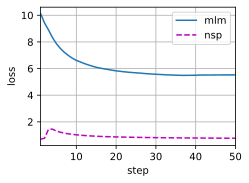

In [66]:
train_bert(train_iter, net, loss, len(vocab), devices, 50) # 显然欠拟合 这里只是做个演示
# 正常可能50要改成1M

In [67]:
def get_bert_encoding(net, tokens_a, tokens_b=None):
    tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)
    token_ids = torch.tensor(vocab[tokens], device=devices[0]).unsqueeze(0)
    segments = torch.tensor(segments, device=devices[0]).unsqueeze(0)
    valid_len = torch.tensor(len(tokens), device=devices[0]).unsqueeze(0)
    encoded_X, _, _ = net(token_ids, segments, valid_len) # 不要loss的输出 只要token
    return encoded_X   

In [68]:
tokens_a = ['a', 'crane', 'is', 'flying']
encoded_text = get_bert_encoding(net, tokens_a)
# 词元：'<cls>','a','crane','is','flying','<sep>'  一共6个  然后128个hiddensize 所以1  6 128 
encoded_text_cls = encoded_text[:, 0, :]
encoded_text_crane = encoded_text[:, 2, :]
encoded_text.shape, encoded_text_cls.shape, encoded_text_crane[0][:3]

(torch.Size([1, 6, 128]),
 torch.Size([1, 128]),
 tensor([ 0.4814, -0.3512, -1.7117], device='cuda:0', grad_fn=<SliceBackward0>))

In [69]:
encoded_text

tensor([[[ 4.0874e-02,  1.2317e+00, -1.9314e+00,  2.6683e-02, -2.1816e-01,
          -4.9596e-01,  1.0994e+00,  1.7874e-01,  2.0143e+00,  2.2974e-01,
          -6.5190e-01, -3.8598e-01, -2.7473e-02, -4.7854e-04, -1.0515e+00,
           2.1903e-01,  2.6098e-01, -4.6043e-01,  2.1890e+00, -6.5777e-01,
           4.7091e-02, -6.5268e-01,  1.1658e-02,  5.4302e-01,  3.3403e-01,
          -1.9448e-01, -1.3644e-02, -1.3712e+00, -4.9217e-01,  8.1467e-01,
           1.7135e-02, -1.4479e+00,  1.9155e-01, -4.9189e-01, -9.3105e-02,
           3.4682e-02, -1.4258e+00,  1.1941e+00,  1.9639e+00, -2.3770e+00,
           9.2225e-01, -7.6714e-01, -1.4296e+00,  1.7952e-02,  1.0294e+00,
          -1.3550e+00,  1.1618e+00,  1.2458e+00,  1.0311e+00,  1.9039e+00,
          -1.2143e+00,  8.2169e-01, -2.1182e+00,  9.0611e-01, -1.6796e-02,
           2.9881e-02,  4.3085e-01, -3.1034e-01,  2.0471e-01,  9.0791e-01,
          -8.7075e-01, -5.7913e-01,  1.1707e+00, -2.3698e+00, -8.7921e-01,
           3.4591e-01,  7

In [70]:
encoded_text_crane

tensor([[ 4.8144e-01, -3.5122e-01, -1.7117e+00, -1.2407e+00,  6.3827e-02,
          4.8848e-01, -1.6446e-01,  2.1828e+00,  6.1506e-01,  8.7089e-01,
         -5.6641e-01, -4.7849e-01, -1.8469e+00, -3.2078e-01, -6.8936e-01,
          2.2698e-01,  1.6411e-01,  2.9232e-01,  2.0863e+00, -3.8645e-02,
         -6.8597e-02, -3.5039e-01, -1.0630e+00, -4.8740e-01,  2.5626e-02,
          1.7936e-01,  8.7610e-02,  3.3627e-02, -3.5091e-01,  1.8898e+00,
          1.9405e+00, -1.1430e+00, -8.6902e-01, -1.6065e+00,  8.4274e-01,
         -3.7576e-01, -1.2417e+00,  9.0164e-02,  9.5036e-01, -1.2553e+00,
          8.7655e-02, -6.1751e-02, -1.8082e+00,  7.7186e-01,  4.8339e-01,
          3.8219e-02,  8.3214e-02,  1.5046e-01,  6.3034e-01,  9.7907e-02,
         -6.0432e-02,  4.5789e-01, -4.3152e-02,  1.0618e-01,  1.2978e+00,
         -2.6372e+00, -4.0387e-01,  2.1481e-01,  1.2215e+00,  4.2228e-02,
         -1.3967e-03, -8.0040e-01,  3.7957e-01, -1.2772e+00, -1.4925e+00,
         -5.5466e-01,  6.7577e-01, -3.

In [71]:
tokens_a, tokens_b = ['a', 'crane', 'driver', 'came'], ['he', 'just', 'left']
encoded_pair = get_bert_encoding(net, tokens_a, tokens_b)
# 词元：'<cls>','a','crane','driver','came','<sep>','he','just',
# 'left','<sep>'
encoded_pair_cls = encoded_pair[:, 0, :]
encoded_pair_crane = encoded_pair[:, 2, :]
encoded_pair.shape, encoded_pair_cls.shape, encoded_pair_crane[0][:3]

(torch.Size([1, 10, 128]),
 torch.Size([1, 128]),
 tensor([0.0130, 0.9203, 0.0555], device='cuda:0', grad_fn=<SliceBackward0>))

## BERT微调

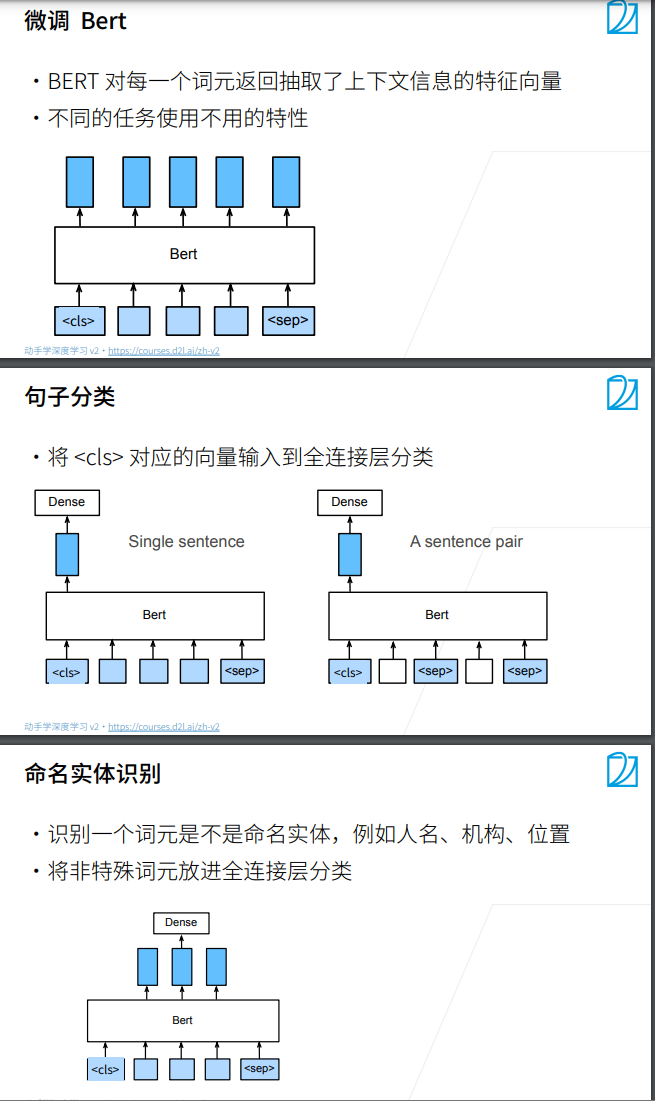
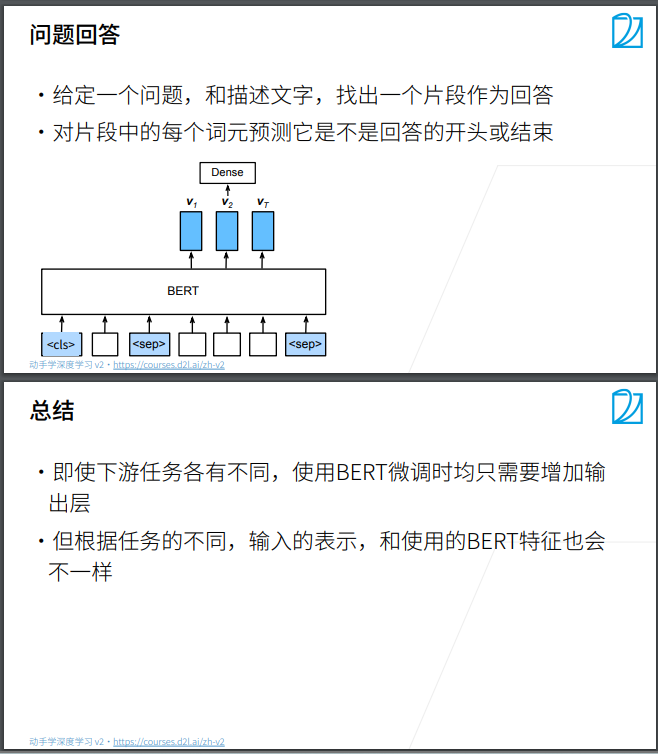

微调的时候每个token视为query 然后输出的大小为batchsize num_hiddens，里面有着句子的上下文信息（但是着重聚焦的是对面的输入的单词）

句子分类是看这个句子是中性的 褒义 贬义这种的， cls作为句子的代表输入是因为在预训练连线题的时候已经将其作为了句子的代表。DENSE以后三分类（中性 褒义 贬义）

实体识别是看是不是专有名词  也是一个个词进行二分化（是或不是）

问题回答中sep前面给的是问题  后面给的是阅读材料。通过遍历阅读材料 dense得到是不是需要的内容（二分化 是或不是）

In [78]:
import os
import re
import torch
from torch import nn
from d2l import torch as d2l

d2l.DATA_HUB['SNLI'] = (
    'https://nlp.stanford.edu/projects/snli/snli_1.0.zip',
    '9fcde07509c7e87ec61c640c1b2753d9041758e4')

data_dir =  '../data/snli_1.0/snli_1.0' 

In [76]:
def read_snli(data_dir, is_train):
    """Read the SNLI dataset into premises, hypotheses, and labels."""
    def extract_text(s):
        s = re.sub('\\(', '', s)
        s = re.sub('\\)', '', s)
        s = re.sub('\\s{2,}', ' ', s)
        return s.strip()
    label_set = {'entailment': 0, 'contradiction': 1, 'neutral': 2}
    file_name = os.path.join(data_dir, 'snli_1.0_train.txt'
                             if is_train else 'snli_1.0_test.txt')
    with open(file_name, 'r') as f:
        rows = [row.split('\t') for row in f.readlines()[1:]]  # 第一行一般是标题 去掉
    premises = [extract_text(row[1]) for row in rows if row[0] in label_set]
    hypotheses = [extract_text(row[2]) for row in rows if row[0] in label_set]
    labels = [label_set[row[0]] for row in rows if row[0] in label_set]
    return premises, hypotheses, labels

In [79]:
train_data = read_snli(data_dir, is_train=True)
for x0, x1, y in zip(train_data[0][:3], train_data[1][:3], train_data[2][:3]):
    print('premise:', x0)
    print('hypothesis:', x1)
    print('label:', y)

premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is training his horse for a competition .
label: 2
premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is at a diner , ordering an omelette .
label: 1
premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is outdoors , on a horse .
label: 0


In [80]:
s = "这   是   一个   测试。"
s = re.sub('\\s{2,}', ' ', s)  # 2代表2个以上  \s代表空格 换行符 制表符  都替换成一个空格
print(s)  # 输出："这是 一个 测试。"

这 是 一个 测试。


In [89]:
s = "    这   是   ((((((一个   测试((((。    "
s = re.sub('\\(', '', s)
s



'    这   是   一个   测试。    '

In [90]:
s.strip()

'这   是   一个   测试。'

In [91]:
test_data = read_snli(data_dir, is_train=False)
for data in [train_data, test_data]:
    print([[row for row in data[2]].count(i) for i in range(3)])

[183416, 183187, 182764]
[3368, 3237, 3219]


In [102]:
a,b,c = train_data

In [103]:
a[0],b[0],c[0]

('A person on a horse jumps over a broken down airplane .',
 'A person is training his horse for a competition .',
 2)

In [115]:
class SNLIDataset(torch.utils.data.Dataset):
    """用于加载SNLI数据集的自定义数据集"""
    def __init__(self,dataset,num_steps,vocab=None):
        self.num_steps = num_steps
        all_premises_tokens = d2l.tokenize(dataset[0],token='word') # all_premises_tokens为一个list of list嵌套列表，列表里面每个元素是每个样本的token词元列表
        all_hypotheses_tokens = d2l.tokenize(dataset[1],token='word') # all_hypotheses_tokens为一个list of list嵌套列表，列表里面每个元素是每个样本的token词元列表
        if vocab is None:
            self.vocab = d2l.Vocab(tokens=all_premises_tokens+all_hypotheses_tokens,min_freq=5,reserved_tokens=['<pad>'])
        else:  # 注意这里需要原本BERT的VOCAB
            self.vocab = vocab
        self.all_premises_tokens = self._pad(all_premises_tokens)
        self.all_hypotheses_tokens = self._pad(all_hypotheses_tokens)
        self.all_labels = torch.tensor(dataset[2])
        print(f'read {len(self.all_premises_tokens)} examples')
    def _pad(self,lines):
        return torch.tensor([d2l.truncate_pad(self.vocab[line],self.num_steps,self.vocab['<pad>']) for line in lines])
    def __getitem__(self, idx):
        return (self.all_premises_tokens[idx],self.all_hypotheses_tokens[idx]),self.all_labels[idx]
    def __len__(self):
        return len(self.all_premises_tokens)


In [116]:
def load_data_snli(batch_size,num_steps = 50):
    """下载SNLI数据集并返回数据迭代器和词表"""
    num_workers = d2l.get_dataloader_workers()
    data_dir = '../data/snli_1.0/snli_1.0' 
    train_data = read_snli(data_dir,is_train=True)
    test_data = read_snli(data_dir,is_train=False)
    train_dataset = SNLIDataset(train_data,num_steps,vocab=None)#训练集需要构建自己的vocab
    test_dataset = SNLIDataset(test_data,num_steps,vocab=train_dataset.vocab)#注意测试集需要使用train_dataset训练集里面的vocab
    train_iter = torch.utils.data.DataLoader(train_dataset,batch_size,shuffle = True,num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(test_dataset,batch_size,shuffle = False,num_workers=num_workers)#测试集里面的shuffle必须是False，也即是每一轮epoch加载一个批量样本时，样本顺序不会改变
    return train_iter,test_iter,train_dataset.vocab


In [117]:
train_iter,test_iter,vocab = load_data_snli(128,50)
len(vocab)


read 549367 examples
read 9824 examples


18678

In [ ]:
#打印第一个批量的相关输入数据和label数据
for X,Y in train_iter:
    print(X[0].shape) #前提的一个批量序列数据
    print(X[1].shape) #假设的一个批量序列数据
    print(Y.shape)  # label的一个批量label数据
    break


In [4]:
# 输出结果如下：
torch.Size([128, 50])
torch.Size([128, 50])
torch.Size([128])


torch.Size([128])

## BERT微调  句子分类

In [3]:
import json
import multiprocessing
import os
import torch
from torch import nn
from d2l import torch as d2l

In [7]:
d2l.DATA_HUB['bert.base'] = (d2l.DATA_URL + 'bert.base.torch.zip',
                             '225d66f04cae318b841a13d32af3acc165f253ac')
d2l.DATA_HUB['bert.small'] = (d2l.DATA_URL + 'bert.small.torch.zip',
                              'c72329e68a732bef0452e4b96a1c341c8910f81f')


# 上一节train的小bert是bertsmall     base是正常版本

In [23]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [19]:
#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(
             num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [13]:
#@save
class BERTEncoder(nn.Module):
    """BERT编码器"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens) # 0或者1
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", EncoderBlock(
                num_hiddens, norm_shape,
                ffn_num_input, ffn_num_hiddens, num_heads, dropout, True))
        # 在BERT中，位置嵌入是可学习的，因此我们创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # 在以下代码段中，X的形状保持不变：（批量大小，最大序列长度，num_hiddens）
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

In [14]:
#@save
class MaskLM(nn.Module):
    """BERT的掩蔽语言模型任务"""
    def __init__(self, vocab_size, num_hiddens, num_inputs=768, **kwargs):
        super(MaskLM, self).__init__(**kwargs)
        self.mlp = nn.Sequential(nn.Linear(num_inputs, num_hiddens),
                                 nn.ReLU(),
                                 nn.LayerNorm(num_hiddens),
                                 nn.Linear(num_hiddens, vocab_size))

    def forward(self, X, pred_positions):  # pred_positions是需要预测的位置
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # 假设batch_size=2，num_pred_positions=3
        # 那么batch_idx是np.array（[0,0,0,1,1,1]）
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        masked_X = X[batch_idx, pred_positions]  # 把对应位置的特征拿出来 用来做分类
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

In [15]:
#@save
class NextSentencePred(nn.Module):
    """BERT的下一句预测任务"""
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)  # 是一个单分类问题

    def forward(self, X):
        # X的形状：(batchsize,num_hiddens)
        return self.output(X)

In [21]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [16]:
#@save
class BERTModel(nn.Module):
    """BERT模型"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 hid_in_features=768, mlm_in_features=768,
                 nsp_in_features=768):
        super(BERTModel, self).__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape,
                    ffn_num_input, ffn_num_hiddens, num_heads, num_layers,
                    dropout, max_len=max_len, key_size=key_size,
                    query_size=query_size, value_size=value_size)
        self.hidden = nn.Sequential(nn.Linear(hid_in_features, num_hiddens),
                                    nn.Tanh())
        self.mlm = MaskLM(vocab_size, num_hiddens, mlm_in_features)
        self.nsp = NextSentencePred(nsp_in_features)

    def forward(self, tokens, segments, valid_lens=None,
                pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        # 用于下一句预测的多层感知机分类器的隐藏层，0是“<cls>”标记的索引
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

In [17]:
def load_pretrained_model(pretrained_model, num_hiddens, ffn_num_hiddens,
                          num_heads, num_layers, dropout, max_len, devices):
    data_dir = d2l.download_extract(pretrained_model)
    # 定义空词表以加载预定义词表
    vocab = d2l.Vocab()
    vocab.idx_to_token = json.load(open(os.path.join(data_dir,
        'vocab.json')))
    vocab.token_to_idx = {token: idx for idx, token in enumerate(
        vocab.idx_to_token)}
    bert = BERTModel(len(vocab), num_hiddens, norm_shape=[256],
                         ffn_num_input=256, ffn_num_hiddens=ffn_num_hiddens,
                         num_heads=4, num_layers=2, dropout=0.2,
                         max_len=max_len, key_size=256, query_size=256,
                         value_size=256, hid_in_features=256,
                         mlm_in_features=256, nsp_in_features=256)
    # 加载预训练BERT参数
    bert.load_state_dict(torch.load(os.path.join(data_dir,
                                                 'pretrained.params')))
    return bert, vocab
    

In [24]:
devices = d2l.try_all_gpus()
bert, vocab = load_pretrained_model(
    'bert.small', num_hiddens=256, ffn_num_hiddens=512, num_heads=4,
    num_layers=2, dropout=0.1, max_len=512, devices=devices)

In [25]:
class SNLIBERTDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, max_len, vocab=None):
        all_premise_hypothesis_tokens = [[
            p_tokens, h_tokens] for p_tokens, h_tokens in zip(
            *[d2l.tokenize([s.lower() for s in sentences])
              for sentences in dataset[:2]])]

        self.labels = torch.tensor(dataset[2])
        self.vocab = vocab
        self.max_len = max_len
        (self.all_token_ids, self.all_segments,
         self.valid_lens) = self._preprocess(all_premise_hypothesis_tokens)
        print('read ' + str(len(self.all_token_ids)) + ' examples')

    def _preprocess(self, all_premise_hypothesis_tokens):
        pool = multiprocessing.Pool(4)  # 使用4个进程  因为python的多线程能力并不是很好
        out = pool.map(self._mp_worker, all_premise_hypothesis_tokens)
        all_token_ids = [
            token_ids for token_ids, segments, valid_len in out]
        all_segments = [segments for token_ids, segments, valid_len in out]
        valid_lens = [valid_len for token_ids, segments, valid_len in out]
        return (torch.tensor(all_token_ids, dtype=torch.long),
                torch.tensor(all_segments, dtype=torch.long),
                torch.tensor(valid_lens))

    def _mp_worker(self, premise_hypothesis_tokens):
        p_tokens, h_tokens = premise_hypothesis_tokens
        self._truncate_pair_of_tokens(p_tokens, h_tokens)
        tokens, segments = d2l.get_tokens_and_segments(p_tokens, h_tokens)
        token_ids = self.vocab[tokens] + [self.vocab['<pad>']] \
                             * (self.max_len - len(tokens))
        segments = segments + [0] * (self.max_len - len(segments))
        valid_len = len(tokens)
        return token_ids, segments, valid_len

    def _truncate_pair_of_tokens(self, p_tokens, h_tokens):
        # 为BERT输入中的'<CLS>'、'<SEP>'和'<SEP>'词元保留位置
        while len(p_tokens) + len(h_tokens) > self.max_len - 3:
            if len(p_tokens) > len(h_tokens):
                p_tokens.pop()
            else:
                h_tokens.pop()

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx]), self.labels[idx]

    def __len__(self):
        return len(self.all_token_ids)

In [ ]:
# 如果出现显存不足错误，请减少“batch_size”。在原始的BERT模型中，max_len=512
batch_size, max_len, num_workers = 512, 128, d2l.get_dataloader_workers()
data_dir = '../data/snli_1.0/snli_1.0' 
train_set = SNLIBERTDataset(d2l.read_snli(data_dir, True), max_len, vocab)
test_set = SNLIBERTDataset(d2l.read_snli(data_dir, False), max_len, vocab)
train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True,
                                   num_workers=num_workers)
test_iter = torch.utils.data.DataLoader(test_set, batch_size,
                                  num_workers=num_workers)

输出结果
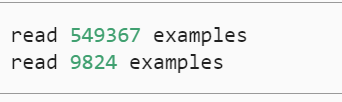

In [ ]:
class BERTClassifier(nn.Module):
    def __init__(self, bert):
        super(BERTClassifier, self).__init__()
        self.encoder = bert.encoder
        self.hidden = bert.hidden  # 这是做连线题的时候 前面也有hidden层 然后linear输出是否是连线的  
        # 这里直接把这个hidden层拿了出来
        self.output = nn.Linear(256, 3)

    def forward(self, inputs):
        tokens_X, segments_X, valid_lens_x = inputs
        encoded_X = self.encoder(tokens_X, segments_X, valid_lens_x)
        return self.output(self.hidden(encoded_X[:, 0, :]))

In [ ]:
net = BERTClassifier(bert)

In [ ]:
lr, num_epochs = 1e-4, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
    devices)

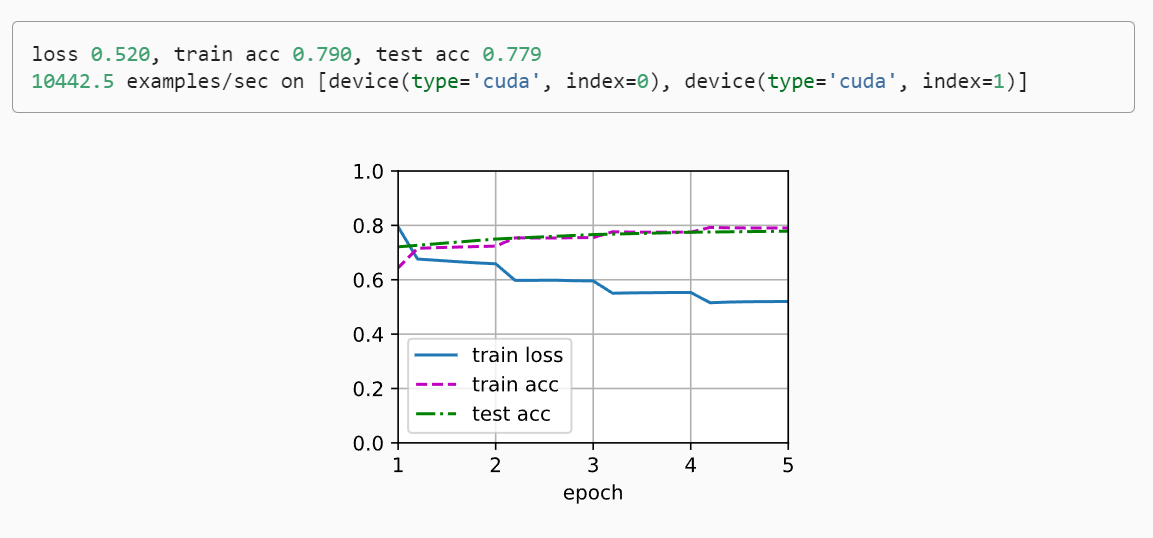

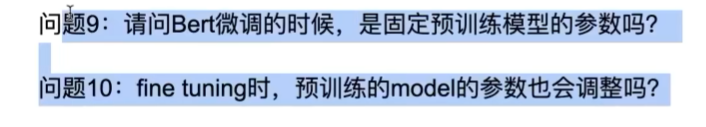
一般不固定 不固定效果会好 但是固定会train更快

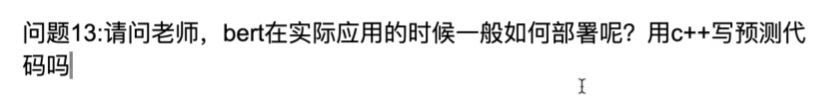
可以全部搬到CPP 但是没有意义 会很慢
一个图片1ms正常   但是100个句子可能才1kb  可能1000个句子就要10ms 100ms了  所以train文本是比图片贵的

In [2]:
import torch
from torch import nn

In [3]:
#@save
class NextSentencePred(nn.Module):
    """BERT的下一句预测任务"""
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)  # 是一个单分类问题

    def forward(self, X):
        # X的形状：(batchsize,num_hiddens)
        return self.output(X)

In [6]:
X = torch.rand((32,256))
X

tensor([[0.1204, 0.6050, 0.4467,  ..., 0.0309, 0.6626, 0.6438],
        [0.1892, 0.4877, 0.9992,  ..., 0.4118, 0.6817, 0.1527],
        [0.9266, 0.3086, 0.5656,  ..., 0.2108, 0.1705, 0.8989],
        ...,
        [0.3624, 0.5491, 0.3984,  ..., 0.0844, 0.7807, 0.6574],
        [0.1378, 0.5022, 0.9864,  ..., 0.0445, 0.0249, 0.2998],
        [0.4810, 0.4695, 0.6855,  ..., 0.4536, 0.1281, 0.1611]])

In [8]:
NextSentencePred(768)(X)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x256 and 768x2)

In [9]:
NextSentencePred(256)(X)

tensor([[ 0.0582, -0.1035],
        [ 0.0771, -0.5646],
        [ 0.4292, -0.4401],
        [ 0.2086, -0.1158],
        [ 0.1494, -0.1139],
        [ 0.3478, -0.3976],
        [ 0.4070, -0.0596],
        [ 0.3020, -0.4867],
        [ 0.0979, -0.2422],
        [ 0.0732, -0.4946],
        [ 0.2116, -0.5083],
        [ 0.3777, -0.3876],
        [ 0.4661, -0.2205],
        [ 0.1832, -0.1825],
        [ 0.2265, -0.6063],
        [ 0.3870, -0.2181],
        [ 0.2067, -0.3156],
        [ 0.2161, -0.2697],
        [ 0.1449, -0.6110],
        [ 0.3893, -0.1752],
        [ 0.3550, -0.2529],
        [ 0.5344, -0.3622],
        [ 0.1936, -0.0680],
        [ 0.2778, -0.4626],
        [ 0.3837, -0.2737],
        [ 0.3399, -0.1282],
        [-0.0149, -0.4071],
        [ 0.1950, -0.5356],
        [ 0.4483, -0.3554],
        [ 0.3421, -0.1386],
        [-0.0437, -0.0405],
        [-0.2231, -0.1243]], grad_fn=<AddmmBackward0>)

In [11]:
hidden = nn.Sequential(nn.Linear(768, 256),
                                    nn.Tanh(),
                                    nn.Linear(768, 2))

In [12]:
hidden(X)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x256 and 768x256)

In [13]:
Y = torch.rand((32,768))

In [14]:
hidden(Y)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x256 and 768x2)

In [15]:
hidden1 = nn.Sequential(nn.Linear(768, 256),
                                    nn.Tanh(),
                                    nn.Linear(256, 2))

In [16]:
hidden1(Y)

tensor([[-0.0308, -0.0016],
        [-0.0120,  0.0382],
        [-0.1427,  0.2247],
        [ 0.0293,  0.0150],
        [ 0.0025, -0.0445],
        [ 0.0055,  0.0759],
        [-0.0957, -0.0448],
        [-0.0143, -0.0468],
        [ 0.0971,  0.0487],
        [ 0.0904, -0.0364],
        [ 0.0513,  0.0235],
        [-0.0628,  0.1350],
        [-0.1235,  0.1043],
        [-0.1679,  0.0533],
        [-0.1877, -0.1136],
        [-0.1401,  0.0388],
        [ 0.0276,  0.0051],
        [-0.0847, -0.0773],
        [-0.0980,  0.0958],
        [-0.0008,  0.0034],
        [ 0.0015,  0.0288],
        [-0.0157,  0.0159],
        [ 0.1129,  0.1210],
        [-0.0794,  0.0353],
        [-0.0472, -0.0276],
        [-0.2023,  0.0078],
        [-0.0583,  0.1058],
        [-0.0229,  0.2412],
        [-0.1244,  0.0160],
        [-0.0214,  0.0765],
        [ 0.0131, -0.1312],
        [-0.0928,  0.0302]], grad_fn=<AddmmBackward0>)

In [17]:
class NextSentencePred(nn.Module):
    """BERT的下一句预测任务

    Defined in :numref:`subsec_mlm`"""
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)

    def forward(self, X):
        # X的形状：(batchsize,num_hiddens)
        return self.output(X)

In [20]:
nn.Sequential(nn.Linear(768, 256),
                                    nn.Tanh(),
             NextSentencePred(256))(Y)

tensor([[ 0.1033,  0.0198],
        [ 0.0902,  0.0636],
        [-0.0427, -0.0364],
        [-0.0204,  0.1282],
        [ 0.0861,  0.0573],
        [ 0.1947, -0.0105],
        [-0.1208, -0.0558],
        [ 0.0504, -0.0920],
        [ 0.0257, -0.0043],
        [ 0.0626,  0.1028],
        [-0.1239, -0.0287],
        [ 0.0680,  0.1350],
        [ 0.0586, -0.0107],
        [ 0.0959,  0.1381],
        [ 0.1298, -0.1909],
        [-0.1317,  0.0211],
        [ 0.0201,  0.1646],
        [ 0.1104,  0.0589],
        [ 0.0371,  0.1151],
        [ 0.0692,  0.2403],
        [-0.0172, -0.0243],
        [-0.0224, -0.0169],
        [-0.1192,  0.0950],
        [ 0.1511,  0.1736],
        [-0.0210,  0.0295],
        [-0.0496, -0.0649],
        [ 0.0643, -0.0107],
        [ 0.0398,  0.0244],
        [-0.0860,  0.1612],
        [-0.1315, -0.1513],
        [-0.0468, -0.0905],
        [-0.0193,  0.1260]], grad_fn=<AddmmBackward0>)